![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 E10 - Pipeline LLM vs Agente IA
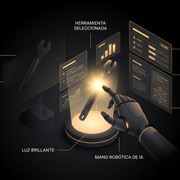

*Figura E10. Reporte de ventas resuelto como pipeline o como agente.*

## Escenario

Tu empresa necesita automatizar un **reporte semanal de ventas**.

En este notebook vas a comparar dos formas de resolver la misma consulta:

1. Un **pipeline LLM tradicional**, que responde texto sin consultar datos.
2. Un **agente IA**, que usa herramientas, observa datos y responde con evidencia.

Todo el contenido esta en castellano para que puedas concentrarte en el problema y en el codigo.


## Conceptos

Un **pipeline LLM** es como pedirle a alguien que responda con lo que recuerda. Puede sonar convincente, pero no necesariamente consulto datos reales.

Un **agente IA** es mas parecido a un analista: antes de responder, consulta datos, calcula y despues arma una respuesta.

```text
Pipeline LLM: consulta -> texto generado
Agente IA: consulta -> herramienta -> observacion -> herramienta -> observacion -> respuesta final
```

La diferencia importante no es el largo del texto. La diferencia es si el sistema actua y observa antes de responder.


## Datos de trabajo


In [ ]:
DATOS_VENTAS = [
    {"semana": "2026-W22", "producto": "Pro", "unidades": 12, "precio_unitario": 30},
    {"semana": "2026-W22", "producto": "Starter", "unidades": 20, "precio_unitario": 12},
    {"semana": "2026-W22", "producto": "Enterprise", "unidades": 3, "precio_unitario": 120},
]

CONSULTA = "Genera el reporte semanal de ventas para 2026-W22"


## Por que importa esta diferencia (comparacion pipeline/agente)

Podemos comparar pipeline y agente con esta tabla:

| Aspecto | LLM Pipeline | AI Agent |
|---|---|---|
| Flujo | Fijo | Dinamico |
| Respuesta | Una sola pasada | Iterativa |
| Uso de herramientas | Predefinido | Seleccionado por el agente |
| Datos en vivo | Limitado | Puede obtenerlos mediante tools |
| Adaptacion ante errores | Baja | Alta |

El **pipeline** funciona bien para:

- clasificacion de texto,
- generacion de emails,
- resumenes de documentos ya conocidos,
- traduccion.

El **agente** aporta valor cuando:

- los datos no estan en el prompt (deben consultarse),
- hay calculos que el LLM podria hacer mal,
- la accion siguiente dentro del agente depende del resultado observado,
- se necesita auditar cada decision.

En este ejercicio, `pipeline_llm` inventa ventas. `pipeline_agente` las consulta.
La diferencia no es el largo del texto: es si la respuesta esta **basada en datos reales**.


## Pipeline tradicional


In [ ]:
def pipeline_llm(consulta: str) -> str:
    """Pipeline simulado: devuelve una respuesta inventada sin usar datos."""
    return (
        "Las ventas parecen fuertes esta semana. "
        "La empresa probablemente vendio alrededor de 1.000 USD "
        "y Pro parece ser el producto principal."
    )


respuesta_pipeline = pipeline_llm(CONSULTA)
print(f"pipeline_llm(CONSULTA) -> {respuesta_pipeline}")


## Herramientas mockeadas


In [ ]:
def buscar_datos_ventas(semana: str) -> list[dict]:
    """Herramienta: busca filas de ventas para una semana."""
    return [fila for fila in DATOS_VENTAS if fila["semana"] == semana]


def calcular_total(filas: list[dict]) -> float:
    """Herramienta: calcula el ingreso total."""
    return sum(fila["unidades"] * fila["precio_unitario"] for fila in filas)


### Qu? debe hacer `pipeline_agente`

Un agente simple necesita estos elementos:

1. **Modelo de lenguaje** -- interpreta la consulta,
2. **Razonamiento** -- decide que pasos seguir,
3. **Tool Use** -- ejecuta herramientas para obtener datos,
4. **Observacion** -- lee los resultados de las tools,
5. **Respuesta final** -- construida desde las observaciones.

El TODO que vas a completar implementa los pasos 3, 4 y 5:

```text
[Accion]      calcular_total(filas)      <- paso 3: ejecutar tool
[Observacion] total = ...               <- paso 4: leer resultado
return "Reporte para {semana}: {total}" <- paso 5: respuesta grounded
```

La respuesta final debe citar los datos observados, no inventar.


## TODO - Pipeline tipo agente


In [ ]:
def pipeline_agente(consulta: str) -> str:
    """Flujo tipo agente: usa herramientas antes de responder."""
    semana = "2026-W22"

    print("[Accion] buscar_datos_ventas")
    filas = buscar_datos_ventas(semana)
    print(f"[Observacion] filas -> {filas}")

    # TODO 1: llamar calcular_total(filas)
    # total = ...

    # TODO 2: devolver una respuesta basada en semana, cantidad de filas y total
    pass


respuesta_agente = pipeline_agente(CONSULTA)
print(f"pipeline_agente(CONSULTA) -> {respuesta_agente}")


## Reflexion final

Ejecutaste la misma consulta con dos enfoques.

Preguntas:

1. ¿Cuál respuesta esta basada en datos?
2. ¿Qué pasaría si `buscar_datos_ventas()` devuelve una lista vacia?
3. ¿Qué haría el pipeline tradicional?
4. ¿Qué podría hacer el agente?

Idea esperada:

- El pipeline probablemente seguiria escribiendo algo convincente.
- El agente podria observar `[]` y responder: "No hay datos para esa semana".


## Cuando NO usar un agente (comparacion pipeline/agente)

Usar un agente cuando no hace falta tiene costos:

- mas complejidad de codigo,
- mayor latencia (mas llamadas, mas ciclos),
- mas dificil de debuggear,
- mayor costo si se usan APIs de IA.

Regla práctica:

> "Un pipeline tradicional sirve para tareas simples. Un agente justifica
> su complejidad cuando la tarea requiere decisiones dinamicas."

Revisa cada caso y decide si usarias pipeline o agente:


In [ ]:
# Ejercicio de reflexion: decidir la arquitectura correcta

casos = [
    "Traducir un texto del espanol al ingles.",
    "Calcular el total de ventas de esta semana desde una base de datos.",
    "Resumir un documento que ya tengo en el prompt.",
    "Verificar si hay stock de un producto y reservarlo si hay unidades.",
    "Clasificar el sentimiento de un tweet (positivo/negativo).",
    "Comparar el precio actual de un producto con el precio de ayer en una API.",
    "Generar el cuerpo de un email de bienvenida dado un nombre de usuario.",
    "Obtener el tipo de cambio actual y convertir facturas pendientes a USD.",
]

# Completar la clasificacion:
# "pipeline" -> no necesita datos externos ni multiples pasos dinamicos
# "agente"   -> requiere consultar datos, calcular o decidir según resultados

arquitectura = {
    casos[0]: "",  # TODO: "pipeline" o "agente"?
    casos[1]: "",  # TODO
    casos[2]: "",  # TODO
    casos[3]: "",  # TODO
    casos[4]: "",  # TODO
    casos[5]: "",  # TODO
    casos[6]: "",  # TODO
    casos[7]: "",  # TODO
}

for caso, decision in arquitectura.items():
    print(f"  [{decision or '?':8s}] {caso}")


### Respuestas esperadas

| Caso | Arquitectura | Por que |
|---|---|---|
| Traducir texto | pipeline | El texto ya esta en el prompt, no hay datos externos. |
| Calcular total desde DB | agente | Necesita consultar datos en vivo. |
| Resumir documento en prompt | pipeline | No necesita tools ni pasos adicionales. |
| Verificar stock y reservar | agente | Consulta datos + ejecuta una accion. |
| Clasificar sentimiento | pipeline | Una sola pasada de LLM alcanza. |
| Comparar precio actual vs ayer | agente | Requiere dos consultas a APIs en vivo. |
| Generar email de bienvenida | pipeline | No necesita datos externos, solo el nombre. |
| Convertir facturas con tipo de cambio | agente | Necesita API de FX + calculo. |
